# 00 — Conversor de Imagens
Converte qualquer formato de imagem (HEIC, PNG, BMP, WEBP, TIFF, etc.) para JPG padronizado.

**Extensões suportadas:** `.HEIC` `.heic` `.PNG` `.png` `.BMP` `.bmp` `.WEBP` `.webp` `.TIFF` `.tiff` `.TIF` `.tif` `.JPEG` `.jpeg` `.JPG` (já em JPG, só copia)

**Entrada:** `data/raw/`  
**Saída:** `data/converted/`

## Célula 1 - Monta o Drive e define caminhos

In [1]:
import os
import sys

# Detecta se está rodando no Colab ou localmente
NO_COLAB = 'google.colab' in sys.modules or 'COLAB_GPU' in os.environ

if NO_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    CAMINHO_BASE = '/content/drive/MyDrive/Colab Notebooks/SinucaVision/data'
else:
    # Caminho local — relativo à raiz do repositório
    CAMINHO_BASE = os.path.join(os.path.dirname(os.getcwd()), 'data')

CAMINHO_RAW       = os.path.join(CAMINHO_BASE, 'raw')
CAMINHO_CONVERTED = os.path.join(CAMINHO_BASE, 'converted')

os.makedirs(CAMINHO_RAW, exist_ok=True)
os.makedirs(CAMINHO_CONVERTED, exist_ok=True)

print(f'Ambiente: {"Google Colab" if NO_COLAB else "Local (JupyterLab/VS Code)"}')
print(f'Raw:       {CAMINHO_RAW}')
print(f'Converted: {CAMINHO_CONVERTED}')

Ambiente: Local (JupyterLab/VS Code)
Raw:       /home/juliana/Projects/UFSC/visao/SinucaVision/data/raw
Converted: /home/juliana/Projects/UFSC/visao/SinucaVision/data/converted


## Célula 2 — Instala dependências

In [2]:
# pillow-heif adiciona suporte a HEIC/HEIF ao Pillow
!pip install pillow-heif -q

## Célula 3 — Converte todas as imagens para JPG

In [3]:
from pillow_heif import register_heif_opener
from PIL import Image, UnidentifiedImageError
import os
import glob

# Registra o suporte a HEIC antes de qualquer abertura
register_heif_opener()

# Todas as extensões aceitas (case-insensitive via glob duplo)
EXTENSOES_SUPORTADAS = [
    '*.HEIC', '*.heic',
    '*.PNG',  '*.png',
    '*.BMP',  '*.bmp',
    '*.WEBP', '*.webp',
    '*.TIFF', '*.tiff',
    '*.TIF',  '*.tif',
    '*.JPEG', '*.jpeg',
    '*.JPG',  '*.jpg',
]

# Coleta todos os arquivos encontrados (sem duplicatas)
arquivos = []
for ext in EXTENSOES_SUPORTADAS:
    arquivos += glob.glob(os.path.join(CAMINHO_RAW, ext))
arquivos = sorted(set(arquivos))

print(f'Pasta verificada: {CAMINHO_RAW}')
print(f'Arquivos encontrados: {len(arquivos)}')
print('-' * 50)

if len(arquivos) == 0:
    print('Nenhuma imagem encontrada na pasta raw/.')
    print('Faça o upload das fotos para o Drive antes de continuar.')
else:
    convertidos  = 0
    ja_existiam  = 0
    erros        = 0

    for idx, caminho_original in enumerate(arquivos, start=1):
        nome_original = os.path.basename(caminho_original)
        # Remove a extensão e força .JPG
        nome_sem_ext  = os.path.splitext(nome_original)[0].upper()
        nome_jpg      = nome_sem_ext + '.JPG'
        caminho_saida = os.path.join(CAMINHO_CONVERTED, nome_jpg)

        # Pula se o JPG já existe (evita reprocessar)
        if os.path.exists(caminho_saida):
            print(f'  [{idx}/{len(arquivos)}] Já existe, pulando: {nome_jpg}')
            ja_existiam += 1
            continue

        try:
            img = Image.open(caminho_original)

            # Converte para RGB — necessário para salvar como JPEG
            # (PNG/WEBP podem ter canal alpha; HEIC pode ter perfil de cor diferente)
            if img.mode not in ('RGB', 'L'):
                img = img.convert('RGB')

            img.save(caminho_saida, 'JPEG', quality=95)
            convertidos += 1
            print(f'  [{idx}/{len(arquivos)}] Convertido: {nome_original} → {nome_jpg}')

        except UnidentifiedImageError:
            print(f'  [{idx}/{len(arquivos)}] ERRO — formato não reconhecido: {nome_original}')
            erros += 1
        except Exception as e:
            print(f'  [{idx}/{len(arquivos)}] ERRO — {nome_original}: {e}')
            erros += 1

    print('-' * 50)
    print(f'Convertidos:    {convertidos}')
    print(f'Já existiam:    {ja_existiam}')
    print(f'Erros:          {erros}')
    print(f'Salvos em:      {CAMINHO_CONVERTED}')

Pasta verificada: /home/juliana/Projects/UFSC/visao/SinucaVision/data/raw
Arquivos encontrados: 56
--------------------------------------------------
  [1/56] Já existe, pulando: IMG_0640.JPG
  [2/56] Já existe, pulando: IMG_0641.JPG
  [3/56] Já existe, pulando: IMG_0642.JPG
  [4/56] Já existe, pulando: IMG_0643.JPG
  [5/56] Já existe, pulando: IMG_0644.JPG
  [6/56] Já existe, pulando: IMG_0645.JPG
  [7/56] Já existe, pulando: IMG_0646.JPG
  [8/56] Já existe, pulando: IMG_0647.JPG
  [9/56] Já existe, pulando: IMG_0648.JPG
  [10/56] Já existe, pulando: IMG_0649.JPG
  [11/56] Já existe, pulando: IMG_0650.JPG
  [12/56] Já existe, pulando: IMG_0651.JPG
  [13/56] Já existe, pulando: IMG_0652.JPG
  [14/56] Convertido: IMG_1032.HEIC → IMG_1032.JPG
  [15/56] Convertido: IMG_1033.HEIC → IMG_1033.JPG
  [16/56] Convertido: IMG_1034.HEIC → IMG_1034.JPG
  [17/56] Convertido: IMG_1035.HEIC → IMG_1035.JPG
  [18/56] Convertido: IMG_1036.HEIC → IMG_1036.JPG
  [19/56] Convertido: IMG_1037.HEIC → IMG_103

## Célula 4 — Visualiza as imagens convertidas (verificação)

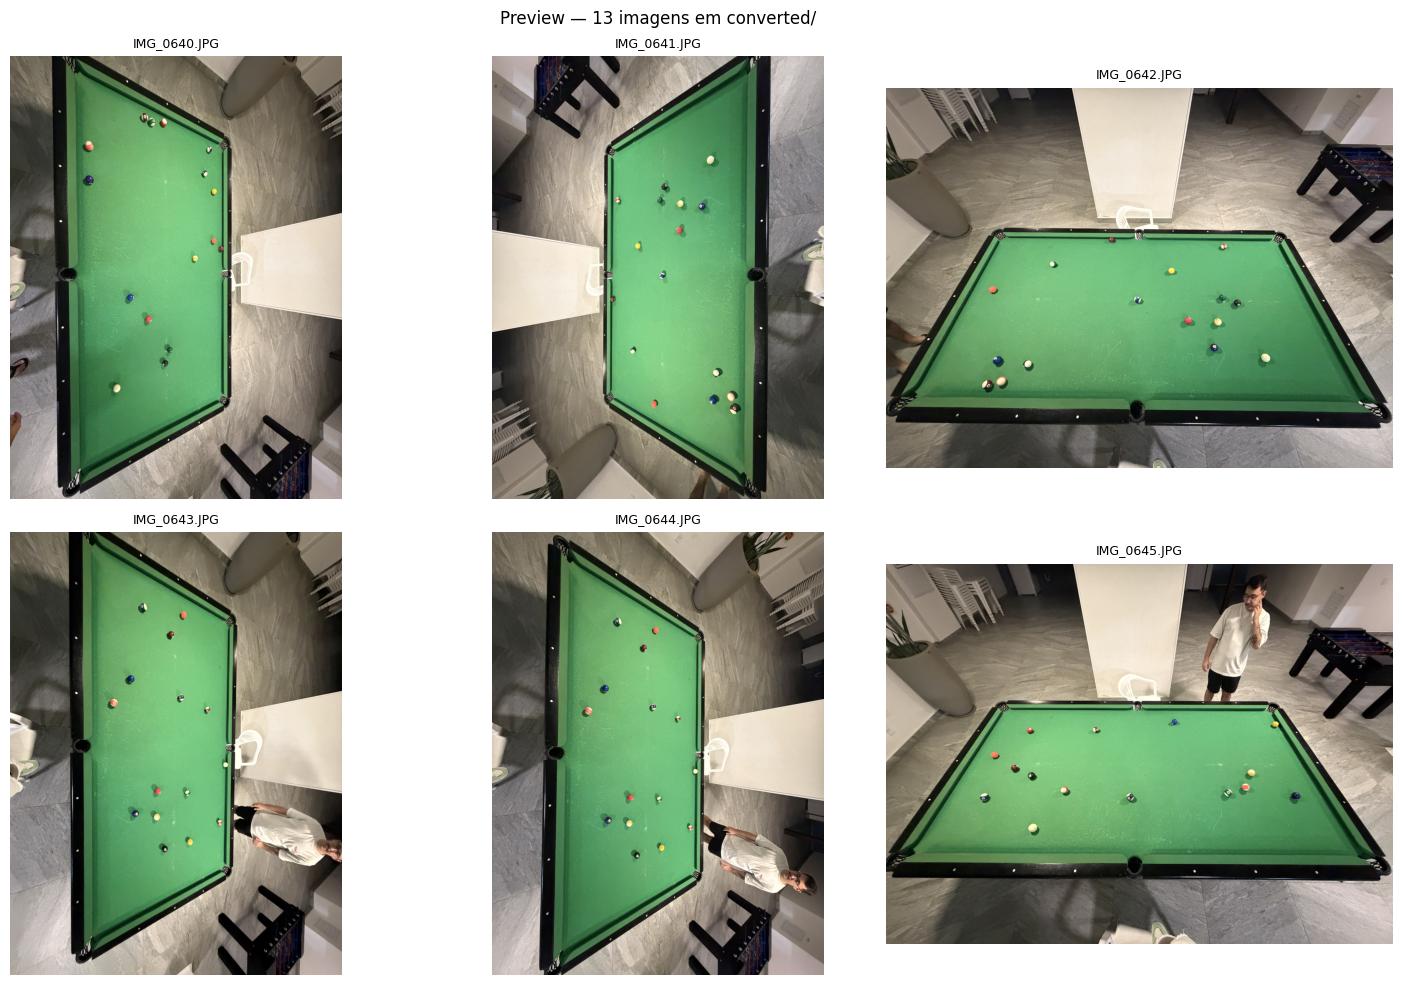

In [7]:
import matplotlib.pyplot as plt
import glob

jpgs = sorted(glob.glob(os.path.join(CAMINHO_CONVERTED, '*.JPG')))

if not jpgs:
    print('Nenhum JPG encontrado em converted/. Execute a Célula 3 primeiro.')
else:
    # Mostra até 6 imagens como grid de preview
    preview = jpgs[:6]
    cols    = 3
    rows    = -(-len(preview) // cols)  # ceil division

    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

    for ax, caminho in zip(axes, preview):
        img = Image.open(caminho)
        ax.imshow(img)
        ax.set_title(os.path.basename(caminho), fontsize=9)
        ax.axis('off')

    # Esconde eixos vazios caso haja menos de 6 imagens
    for ax in axes[len(preview):]:
        ax.axis('off')

    plt.suptitle(f'Preview — {len(jpgs)} imagens em converted/', fontsize=12)
    plt.tight_layout()
    plt.show()